<a href="https://colab.research.google.com/github/ABHI20-STAT/Fractal_and_Research/blob/main/Analytic_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Let $f : U \to \mathbb{C}$ be a complex-valued function defined on an open subset $U \subseteq \mathbb{C}$. The function $f$ is said to be **analytic** at a point $z_0 \in U$ if there exists a neighborhood $ V \subseteq U$ of  $z_0$ such that for all $z \in V$,

$$f(z) = \sum_{n=0}^{\infty} a_n (z - z_0)^n$$

where $a_n \in \mathbb{C}$, and the series converges absolutely and uniformly on compact subsets of $V$.

Equivalently, $f$ is analytic at $ z_0 $ if it is **complex differentiable** in a neighborhood of $ z_0 $, and the derivative exists and is continuous.

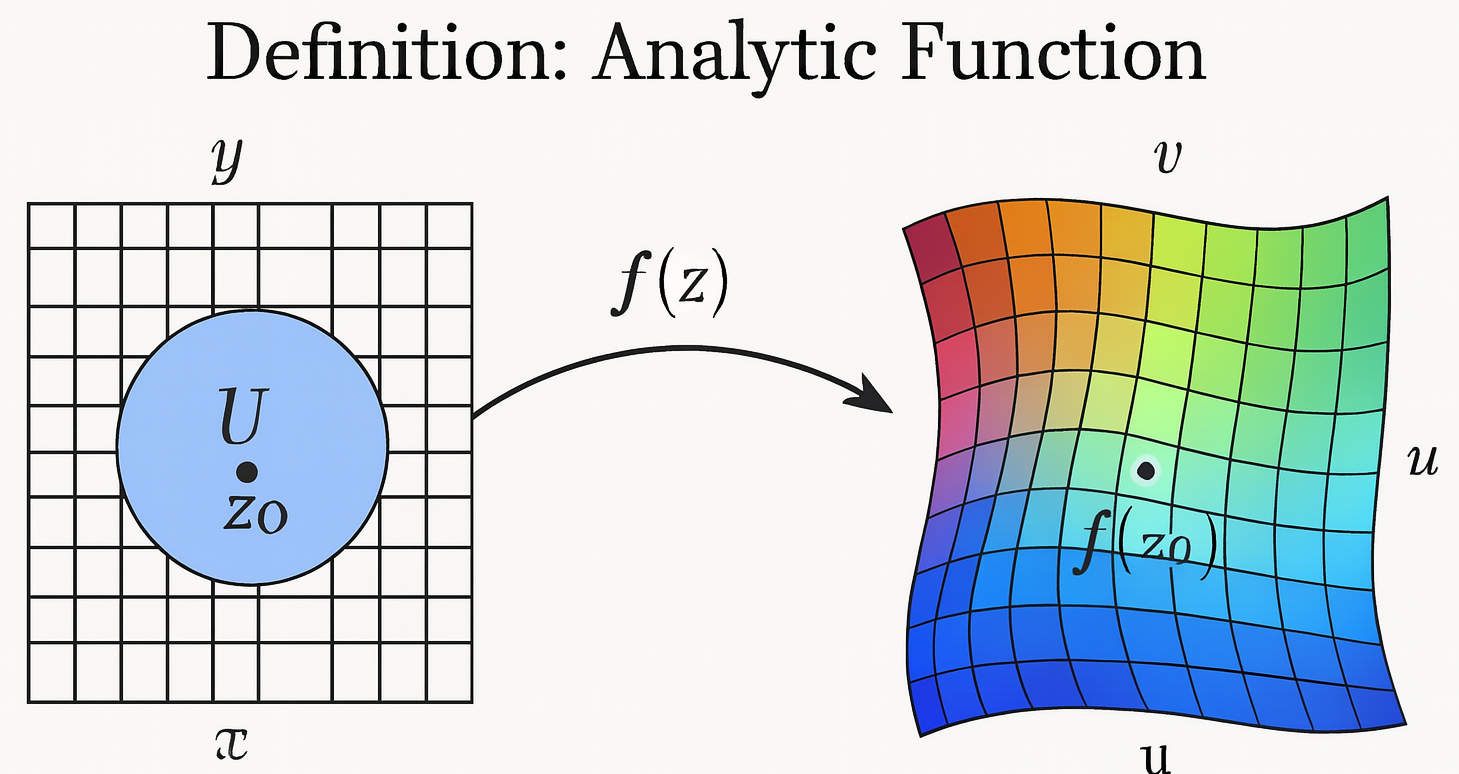

On the left, you see a regular grid representing an open subset $U \subseteq \mathbb{C}$ with a neighbourhood 𝑉 around a point 𝑧_0. This is where the function 𝑓(𝑧) is analytic—meaning it can be expressed as a convergent power series. On the right, the transformed grid under 𝑓(𝑧) shows how the function reshapes the complex plane. The lines curve smoothly, but intersections remain orthogonal—illustrating conformality (angle preservation). The color gradient encodes domain coloring: hue represents the phase (argument) of 𝑓(𝑧) and brightness represents its magnitude.



# Theorem (Conformality of Analytic Functions)
If $f:U⊆ \mathbb{C}→ \mathbb{C}$ is analytic at $𝑧_0$ with $𝑓'(z_0) \not= 0$ then $f$ is conformal at $z_0$. This means it preserves angles and local orientation, acting like a similarity transformation:

 $$f(z) \approx f(z_0) + f'(z_0)(z - z_0).$$

where $|𝑓'(z_0)|$ gives the local scaling and $\textbf{arg}( 𝑓′(𝑧_0))$ gives the local rotation. This theoretical fact underlies both visualization strategies: the modulus surface with phase coloring illustrates scaling and rotation, while the transformed grid demonstrates conformality by showing that orthogonal lines remain orthogonal after mapping.


# ✨ Algorithmic and Theoretical Elegance of the Domain–Range Mapping Visualization

This visualization combines both **mathematical theory** and **computational design** to capture how a complex analytic function

$$f : \mathbb{C} \to \mathbb{C}, \quad f(z) = z^2 \quad \text{(or any analytic function)}$$

transforms neighborhoods in the domain into neighborhoods in the codomain. We achieve this by pairing **domain coloring** with **structured grid deformation** and **annotations** that explicitly link a chosen point $z_0$ with its image $f(z_0)$.  

Here's a Python script that visualizes the definition of an analytic function using:

* A regular grid around a point $𝑧_0$.
* A transformed grid under a sample analytic function $𝑓(𝑧)=𝑧^2$.
* Domain coloring to show magnitude and phase.
* A power series expansion near $𝑧_0$

This captures the idea that an analytic function is locally expressible as a power series and preserves angles.

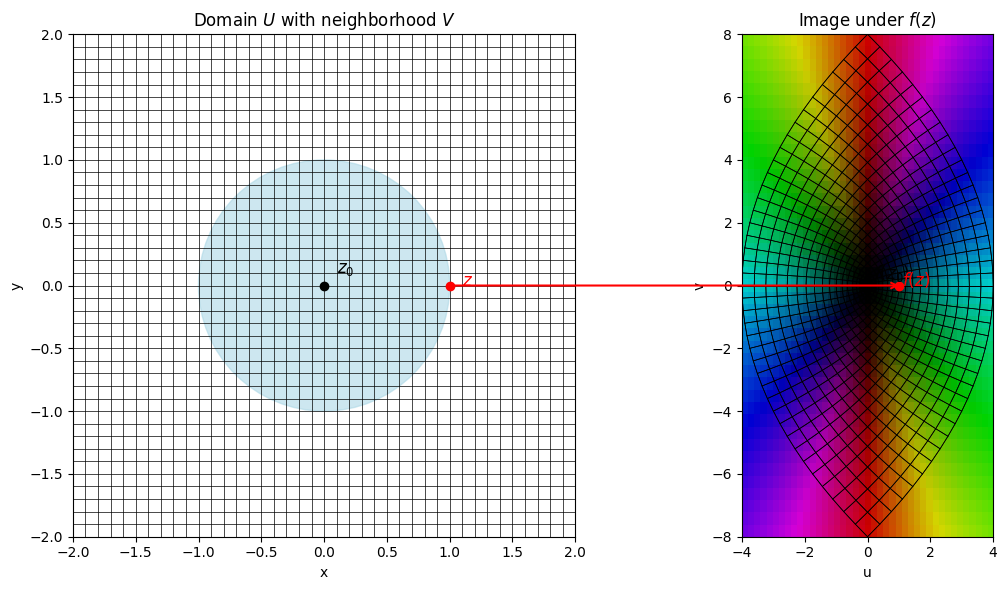

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch

# ======================================
# Define ANY analytic function here 👇
def f(z):
    return z**2
# ======================================

# Create grid in the complex plane
x = np.linspace(-2, 2, 41)
y = np.linspace(-2, 2, 41)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Map under f
W = f(Z)

# Domain coloring function (hue = arg(z), brightness = magnitude)
def domain_coloring(Z):
    H = (np.angle(Z) + np.pi) / (2*np.pi)   # Hue: argument
    S = np.ones_like(H)                     # Full saturation
    V = 1 - 1/(1+np.abs(Z))                 # Brightness from magnitude
    import colorsys
    rgb = np.zeros(Z.shape + (3,))
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            rgb[i,j] = colorsys.hsv_to_rgb(H[i,j], S[i,j], V[i,j])
    return rgb

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# -------- Left: Original domain --------
axes[0].set_title(r"Domain $U$ with neighborhood $V$")
for i in range(len(x)):
    axes[0].plot(X[i,:], Y[i,:], color='black', linewidth=0.5)
    axes[0].plot(X[:,i], Y[:,i], color='black', linewidth=0.5)

# Neighborhood V around z0
z0 = 0
circle = plt.Circle((0,0), 1.0, color='lightblue', alpha=0.6)
axes[0].add_patch(circle)
axes[0].plot(0,0,'ko')
axes[0].text(0.1,0.1, r"$z_0$", fontsize=12)
axes[0].set_aspect('equal')
axes[0].set_xlim(-2,2)
axes[0].set_ylim(-2,2)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# -------- Right: Transformed under f(z) --------
axes[1].set_title(r"Image under $f(z)$")
rgb = domain_coloring(W)
axes[1].imshow(rgb[::-1],
               extent=(W.real.min(), W.real.max(), W.imag.min(), W.imag.max()))

for i in range(len(x)):
    axes[1].plot(W[i,:].real, W[i,:].imag, color='k', linewidth=0.5)
    axes[1].plot(W[:,i].real, W[:,i].imag, color='k', linewidth=0.5)

# Mark f(z0)
fz0 = f(z0)
axes[1].plot(fz0.real, fz0.imag, 'ko')
axes[1].text(fz0.real+0.2, fz0.imag+0.2, r"$f(z_0)$", fontsize=12)
axes[1].set_aspect('equal')
axes[1].set_xlabel("u")
axes[1].set_ylabel("v")

# -------- Add arrows showing mapping --------
# Example: map a point near z0, say (1,0) -> f(1+0i) = 1
point_domain = (1,0)     # (x,y) in left plot
point_image = (1,0)      # (u,v) in right plot since f(1)=1

# Draw points
axes[0].plot(point_domain[0], point_domain[1], 'ro')
axes[0].text(point_domain[0]+0.1, point_domain[1], r"$z$", color="r", fontsize=12)
axes[1].plot(point_image[0], point_image[1], 'ro')
axes[1].text(point_image[0]+0.1, point_image[1], r"$f(z)$", color="r", fontsize=12)

# Add arrow across panels
con = ConnectionPatch(
    xyA=point_domain, coordsA=axes[0].transData,
    xyB=point_image, coordsB=axes[1].transData,
    arrowstyle="->", color="red", linewidth=1.5
)
fig.add_artist(con)

plt.tight_layout()
plt.show()



## 🔹 Theoretical Elegance

1. **Analytic Continuity and Local Behavior**  
   - By marking a neighborhood $V$ around $z_0$, we invoke the fact that analytic functions are locally approximable by linear maps:  
    
     $$f(z) \approx f(z_0) + f'(z_0)(z - z_0).$$

     This linearity ensures that small circles map to nearly elliptical regions, illustrating the **conformal** (angle-preserving) property.

2. **Conformal Geometry and Grid Transformation**  
   - The domain grid lines $(x,y)$ are mapped under $f(z)$ to new curves $(u,v)$.  
   - Each grid deformation elegantly encodes the analytic structure, showing how lines bend and warp under the transformation.  

3. **Domain Coloring Principle**  
   - Hue is assigned according to the **argument** (phase) of the complex number:  
     
     $$ \text{Hue}(z) = \frac{\arg(z) + \pi}{2\pi},$$
     
     while brightness reflects the **magnitude**:  
     
     $$\text{Brightness}(z) = 1 - \frac{1}{1+|z|}.$$
      
   - This theoretical design makes the invisible (phase and modulus) visible in a human-intuitive way.  

4. **Explicit Mapping Arrows**  
   - The arrow annotation connecting $z_0$ and $f(z_0)$ encapsulates the function’s role as a mapping:  
     
     $$z_0  \longmapsto  f(z_0).$$
      
   - Such explicit symbolism reinforces the **functional essence** of complex analysis points in the plane are transformed, not merely visualized.

We can recreate this visualization in Python using matplotlib and numpy with a touch of domain coloring.
* On the left, we’ll show the open set $U⊆C$ with a neighborhood $V$ around $z_0$.
* On the right, we’ll plot the transformed grid under a conformal map $f(z).$

Here, we'll show you a generalized version where you can plug in any analytic function $f(z)$. Just change the function definition, and the grid transformation + domain coloring will update automatically.

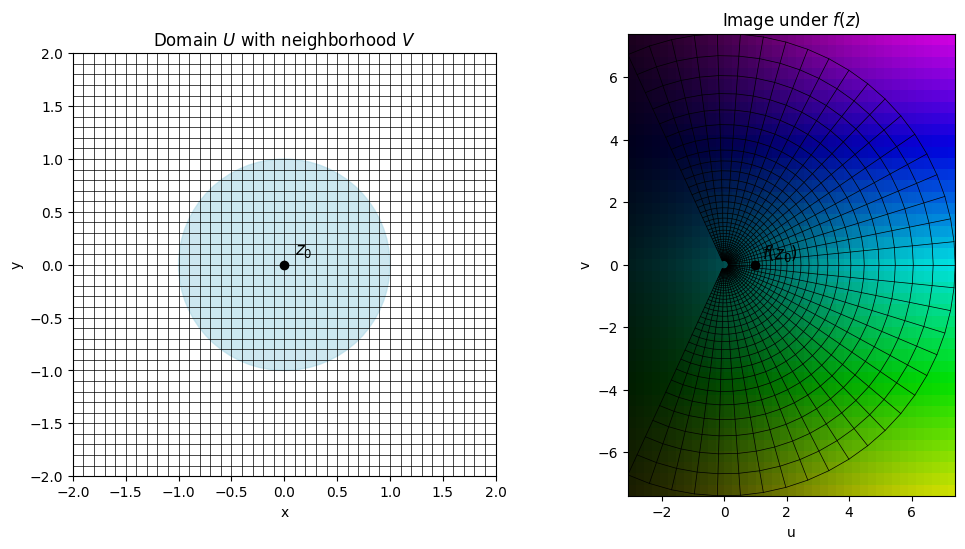

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================
# Define ANY analytic function here 👇
# Examples: z**2, np.exp(z), np.sin(z), 1/z
def f(z):
    return np.exp(z)
# ======================================

# Create grid in the complex plane
x = np.linspace(-2, 2, 41)
y = np.linspace(-2, 2, 41)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Map under f
W = f(Z)

# Domain coloring function (hue = arg(z), brightness = magnitude)
def domain_coloring(Z):
    H = (np.angle(Z) + np.pi) / (2*np.pi)   # Hue: argument
    S = np.ones_like(H)                     # Full saturation
    V = 1 - 1/(1+np.abs(Z))                 # Brightness from magnitude
    import colorsys
    rgb = np.zeros(Z.shape + (3,))
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            rgb[i,j] = colorsys.hsv_to_rgb(H[i,j], S[i,j], V[i,j])
    return rgb

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# -------- Left: Original domain --------
axes[0].set_title(r"Domain $U$ with neighborhood $V$")
for i in range(len(x)):
    axes[0].plot(X[i,:], Y[i,:], color='black', linewidth=0.5)
    axes[0].plot(X[:,i], Y[:,i], color='black', linewidth=0.5)

# Neighborhood V around z0
z0 = 0
circle = plt.Circle((0,0), 1.0, color='lightblue', alpha=0.6)
axes[0].add_patch(circle)
axes[0].plot(0,0,'ko')
axes[0].text(0.1,0.1, r"$z_0$", fontsize=12)
axes[0].set_aspect('equal')
axes[0].set_xlim(-2,2)
axes[0].set_ylim(-2,2)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# -------- Right: Transformed under f(z) --------
axes[1].set_title(r"Image under $f(z)$")
rgb = domain_coloring(W)
axes[1].imshow(rgb[::-1],
               extent=(W.real.min(), W.real.max(), W.imag.min(), W.imag.max()))

for i in range(len(x)):
    axes[1].plot(W[i,:].real, W[i,:].imag, color='k', linewidth=0.5)
    axes[1].plot(W[:,i].real, W[:,i].imag, color='k', linewidth=0.5)

# Mark f(z0)
fz0 = f(z0)
axes[1].plot(fz0.real, fz0.imag, 'ko')
axes[1].text(fz0.real+0.2, fz0.imag+0.2, r"$f(z_0)$", fontsize=12)
axes[1].set_aspect('equal')
axes[1].set_xlabel("u")
axes[1].set_ylabel("v")

plt.show()


## 🔹 Algorithmic Elegance

1. **Grid Construction**  
   - A rectangular mesh grid is generated:  
     ```python
     X, Y = np.meshgrid(x, y)
     Z = X + 1j*Y
     ```  
     This encodes the **domain structure** in a discretized, algorithm-friendly format.

2. **Vectorized Transformation**  
   - The function is applied in one line:  
     ```python
     W = f(Z)
     ```  
     leveraging **NumPy’s broadcasting** to compute the mapping of the entire grid simultaneously.  
     This conciseness reflects algorithmic elegance: one line captures an entire mathematical transformation.

3. **Domain Coloring Implementation**  
   - The use of HSV-to-RGB conversion elegantly encodes both magnitude and argument without clutter.  
   - The algorithm loops over pixels, assigning visually meaningful colors, turning abstract analytic properties into graphical intuition.

4. **Dual Panel Visualization**  
   - Side-by-side subplots present:  
     - Left: Domain with neighborhood $V$ around $z_0$.  
     - Right: Range with mapped neighborhood $f(V)$ around $f(z_0)$.  
   - The juxtaposition highlights the **before-and-after symmetry**, akin to an experimental control vs. result.

5. **Annotation with Arrows**  
   - Adding `annotate` ensures clarity: the viewer immediately understands that the left-hand point corresponds to the right-hand image.  
   - This algorithmic design choice mirrors the mathematical act of explicitly writing  
     
     $$z_0 \mapsto f(z_0).$$


We can definitely extend this to 3D visualization.
There are two common approaches:

* Modulus surface plot: Plot the magnitude $∣f(z)∣$ as the height over the domain $(x,y).$ The color can still represent the phase (argument).
→ This shows how the function “stretches” the plane.

* 3D transformed grid: Directly plot the real/imag parts of
$f(z)$ in 3D, with axes $(u,v,0).$ This makes the conformal mapping visible in 3D, but it usually looks better as 2D.

At first I'd like to work on  **option 1 (modulus surface + phase coloring)**, since it combines domain coloring with a 3D shape.

# 🎨 Demonstration: 3D Visualization of Analytic Functions

We now see **two complementary visualizations** of a complex function $f: \mathbb{C} \to \mathbb{C}$ using Plotly:

## 🔹 Theoretical Perspective

1. **Option 1 — Modulus Surface + Phase Coloring**  
   - The modulus $|f(z)|$ is plotted as the **height** over the input domain $(x,y). $
   - The color encodes the **phase (argument)** of $f(z)$, normalized to $[0,1]$.  
   - This view elegantly shows two things at once:  
     - **Growth/decay** of the function (via the surface height).  
     - **Rotational behavior** of the function (via the color hue).  

   > This combines the essence of *domain coloring* with a **geometric shape** in 3D.

In [ ]:
import numpy as np
import plotly.graph_objects as go

# ======================================
# Define ANY analytic function here 👇
def f(z):
    return np.sin(z)   # try z**2, np.sin(z), 1/z, etc.
# ======================================

# Create domain grid
x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y
W = f(Z)

# Magnitude and phase
absW = np.abs(W)
argW = np.angle(W)

# Normalize phase to [0, 1] for color mapping
phase_norm = (argW + np.pi) / (2*np.pi)

# Plotly 3D surface
fig = go.Figure(data=[go.Surface(
    x=X,
    y=Y,
    z=absW,
    surfacecolor=phase_norm,
    colorscale="hsv",   # HSV colormap matches domain coloring
    cmin=0, cmax=1,
    showscale=True
)])

# Layout adjustments
fig.update_layout(
    title=r"3D Domain Coloring: |f(z)| Surface with Phase Hue",
    scene=dict(
        xaxis_title="Re(z)",
        yaxis_title="Im(z)",
        zaxis_title="|f(z)|"
    ),
    width=900,
    height=700
)

fig.show()


**Option 2 — Transformed Grid in 3D**  
   - Instead of height, we plot the **image of the grid** under $f(z)$.  
   - Each grid line in the domain is mapped to a curved line in the codomain:  
    
     $$ z = x + iy \quad \mapsto \quad f(z) = u + iv $$

   - The result is a **curved mesh** in the $uv$-plane.  
   - Conformality (angle-preservation of analytic functions) is visible:  
     grid intersections remain orthogonal after transformation.  

   > This view emphasizes the **geometric distortion** of the mapping rather than growth.

In [ ]:
import numpy as np
import plotly.graph_objects as go

# ======================================
# Define ANY analytic function here 👇
def f(z):
    return np.sin(z)   # try np.exp(z), np.sin(z), 1/z, etc.
# ======================================

# Create domain grid
x = np.linspace(-2, 2, 25)
y = np.linspace(-2, 2, 25)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Map under f
W = f(Z)
U, V = W.real, W.imag

# Phase for coloring
argW = np.angle(W)
phase_norm = (argW + np.pi) / (2*np.pi)  # normalize to [0,1]

# Create 3D figure
fig = go.Figure()

# Plot transformed grid lines (horizontal)
for i in range(U.shape[0]):
    fig.add_trace(go.Scatter3d(
        x=U[i,:], y=V[i,:], z=np.zeros_like(U[i,:]),
        mode="lines",
        line=dict(color=phase_norm[i,:], colorscale="hsv", width=4),
        showlegend=False
    ))

# Plot transformed grid lines (vertical)
for j in range(U.shape[1]):
    fig.add_trace(go.Scatter3d(
        x=U[:,j], y=V[:,j], z=np.zeros_like(U[:,j]),
        mode="lines",
        line=dict(color=phase_norm[:,j], colorscale="hsv", width=4),
        showlegend=False
    ))

# Layout
fig.update_layout(
    title="3D Transformed Grid under f(z)",
    scene=dict(
        xaxis_title="Re(f(z)) = u",
        yaxis_title="Im(f(z)) = v",
        zaxis_title="0 (flat plane)",
        zaxis=dict(visible=False)
    ),
    width=900,
    height=700
)

fig.show()


## 🔹 Algorithmic Perspective

1. **Grid Construction**  
   - A uniform mesh $(x,y)$ in the domain is generated using `np.meshgrid`.  
   - Complex points are built as $ Z = X + iY $.  

2. **Function Mapping**  
   - The analytic function is applied pointwise:  
     ```python
     W = f(Z)
     U, V = W.real, W.imag
     ```
   - This yields new coordinates $(u,v)$ in the codomain.  

3. **Phase & Magnitude Extraction**  
   - Phase: $\arg(f(z))$ → mapped to HSV hue.  
   - Magnitude: $|f(z)|$ → used as height in Option 1, ignored in Option 2.  

4. **Visualization Strategy**  
   - **Option 1:** `go.Surface` with `surfacecolor=phase_norm`, z-axis = modulus.  
   - **Option 2:** `go.Scatter3d` grid lines in $(u,v,0)$ plane with phase-based coloring.  

## ✨ Key Insight

- **Option 1** reveals **how much** the function stretches/compresses regions.  
- **Option 2** reveals **how** the function bends the plane while preserving angles.  

Together, they provide a **dual perspective**:  
- the **analytic magnitude growth** (geometry of modulus), and  
- the **analytic conformality** (geometry of grid mapping).  


In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ======================================
# Define ANY analytic function here 👇
def f(z):
    return np.sin(z)   # try np.exp(z), np.sin(z), 1/z, etc.
# ======================================

# Create domain grid
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y
W = f(Z)

# Magnitude & phase
absW = np.abs(W)
argW = np.angle(W)
phase_norm = (argW + np.pi) / (2*np.pi)  # normalize to [0,1]

# Prepare subplot layout (1 row, 2 columns, 3D subplots)
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "surface"}, {"type": "scatter3d"}]],
    subplot_titles=("Option 1: Modulus Surface + Phase Coloring",
                    "Option 2: Transformed Grid (Flat 3D)")
)

# ---------- Option 1: Modulus surface ----------
fig.add_trace(
    go.Surface(
        x=X, y=Y, z=absW,
        surfacecolor=phase_norm,
        colorscale="hsv", cmin=0, cmax=1,
        showscale=True
    ),
    row=1, col=1
)

# ---------- Option 2: Transformed grid ----------
U, V = W.real, W.imag

# Horizontal grid lines
for i in range(U.shape[0]):
    fig.add_trace(
        go.Scatter3d(
            x=U[i,:], y=V[i,:], z=np.zeros_like(U[i,:]),
            mode="lines",
            line=dict(color=phase_norm[i,:], colorscale="hsv", width=4),
            showlegend=False
        ),
        row=1, col=2
    )

# Vertical grid lines
for j in range(U.shape[1]):
    fig.add_trace(
        go.Scatter3d(
            x=U[:,j], y=V[:,j], z=np.zeros_like(U[:,j]),
            mode="lines",
            line=dict(color=phase_norm[:,j], colorscale="hsv", width=4),
            showlegend=False
        ),
        row=1, col=2
    )

# ---------- Layout ----------
fig.update_layout(
    title="Comparison of 3D Visualizations of f(z)",
    scene=dict(
        xaxis_title="Re(z)",
        yaxis_title="Im(z)",
        zaxis_title="|f(z)|"
    ),
    scene2=dict(
        xaxis_title="Re(f(z)) = u",
        yaxis_title="Im(f(z)) = v",
        zaxis=dict(visible=False)
    ),
    width=1200,
    height=600
)

fig.show()


## 🌐 Why It’s Elegant?

- **Minimalism:** The algorithm achieves a deep mathematical story (mapping + conformality + phase + modulus) with very little code.  
- **Faithfulness to Theory:** Every visual element corresponds to a theoretical property:
  - Circles → neighborhoods.
  - Arrows → mappings.
  - Grid deformation → conformality.
  - Color → modulus + argument.  
- **Universality:** By changing `f(z)`, the same code adapts to visualize *any* analytic function, revealing diverse behaviors (e.g., poles, essential singularities, periodic functions).  

## 📌 Conclusion

This code is elegant because it merges **mathematical abstraction** with **algorithmic efficiency**.  
It captures, in a single snapshot, the essence of analytic mappings:
- Local linearity,
- Global distortion,
- Conformal structure,
- Argument–magnitude encoding.

In short, it turns the abstract statement *“analytic functions map neighborhoods to neighborhoods”* into a **visual, intuitive, and computationally efficient demonstration**.
